In [ ]:
import cv2
import numpy as np
from pdf2image import convert_from_path
import os

# --- AYARLAR ---
pdf_path = 'sinav.pdf'  # PDF dosyanızın adı (5 sayfalık dosya)
output_folder = 'optik_kirpilmis_resimler'
dpi = 300  # Hassas okuma için yüksek DPI

if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# 1. PDF'i Görüntülere Çevir (Tüm sayfalar)
print(f"'{pdf_path}' dosyası okunuyor, lütfen bekleyin...")
try:
    pages = convert_from_path(pdf_path, dpi=dpi)
    print(f"Toplam {len(pages)} sayfa tespit edildi.")
except Exception as e:
    print(f"Hata: PDF dosyası okunamadı. Detay: {e}")
    pages = []

# 2. Her Sayfayı Tek Tek İşle
for i, page in enumerate(pages):
    # PIL formatından OpenCV formatına çevir
    img = cv2.cvtColor(np.array(page), cv2.COLOR_RGB2BGR)
    h, w = img.shape[:2]
    
    # Sağ alt köşedeki optik alanı hedefle
    # Formun büyüklüğüne göre buradaki 0.45 ve 0.55 oranlarını 
    # hassas ayar (fine-tune) yaparak değiştirebilirsiniz.
    crop_w = int(w * 0.45) # Sayfa genişliğinin sağdan %45'i
    crop_h = int(h * 0.55) # Sayfa yüksekliğinin alttan %55'i
    
    # Kesme işlemi
    cropped_area = img[h - crop_h : h, w - crop_w : w]
    
    # 3. Her Sayfa İçin Ayrı İsimle Kaydet
    file_name = f"ogrenci_{i+1}.png"
    save_path = os.path.join(output_folder, file_name)
    
    cv2.imwrite(save_path, cropped_area)
    print(f"Kaydedildi: {file_name} (Boyut: {cropped_area.shape[1]}x{cropped_area.shape[0]})")

print("\nİşlem tamamlandı. 'optik_kirpilmis_resimler' klasörünü kontrol edebilirsiniz.")

'bos_sinav.pdf' dosyası okunuyor, lütfen bekleyin...
Toplam 1 sayfa tespit edildi.
Kaydedildi: ogrenci_1.png (Boyut: 1116x1929)

İşlem tamamlandı. 'optik_kirpilmis_resimler' klasörünü kontrol edebilirsiniz.


ROI boyutu: (500, 640)
Sütun  1: 1  (satır 1, alan=1958)
Sütun  2: 0  (satır 1, alan=1894)
Sütun  3: A  (satır 1, alan=1514)
Sütun  4: H  (satır 1, alan=1034)
Sütun  5: A  (satır 1, alan=1964)
Sütun  6: A  (satır 1, alan=1724)
Sütun  7: 0  (satır 1, alan=1664)
Sütun  8: 0  (satır 1, alan=1866)
Sütun  9: 0  (satır 1, alan=1918)
Sütun 10: 0  (satır 1, alan=1552)

ÖĞRENCİ NUMARASI: 10AHAA0000


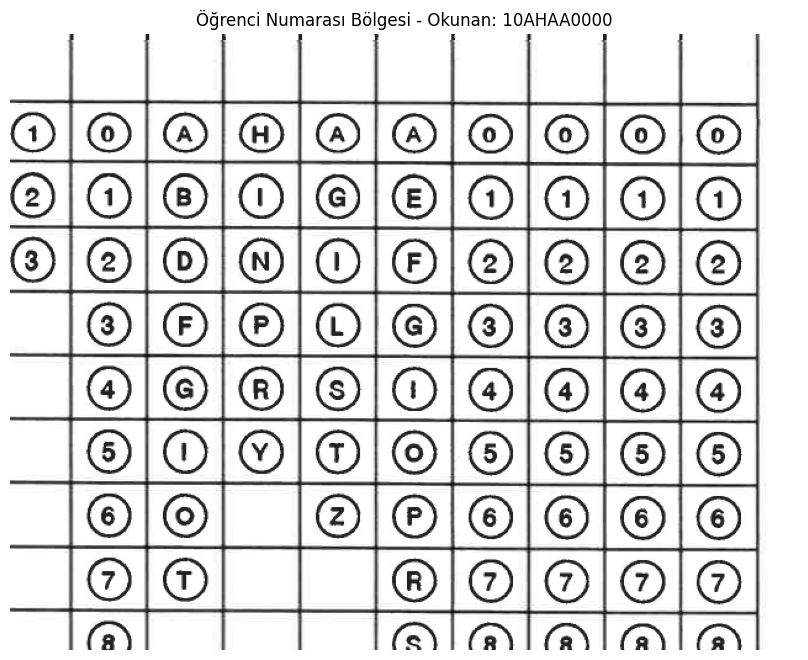

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ====================== AYARLAR ======================
image_path = 'optik_kirpilmis_resimler/ogrenci_1.png'          # <-- Dosya adını buraya yaz

# Öğrenci numarası bölgesinin yaklaşık koordinatları (görüntüne göre gerekirse değiştir)
# Format: [y1:y2, x1:x2]
student_roi = [80, 580, 40, 680]      # [üst, alt, sol, sağ] - piksel

# Her sütunun genişliği yaklaşık (10 sütun)
column_width = 58                     # piksel (görüntüye göre ayarla)

# Sütun seçenekleri (senin verdiğin liste)
options = [
    ["1", "2", "3"],                                   # Sütun 1
    ["0","1","2","3","4","5","6","7","8","9"],         # Sütun 2
    ["A", "B", "D", "F", "G", "İ", "O", "T"],          # Sütun 3
    ["H", "I", "N", "P", "R", "Y"],                    # Sütun 4
    ["A", "G", "İ", "L", "Ş", "T", "Z"],               # Sütun 5
    ["A", "E", "F", "G", "İ", "Ö", "P", "R", "S", "T", "Z"], # Sütun 6
    ["0","1","2","3","4","5","6","7","8","9"],         # Sütun 7
    ["0","1","2","3","4","5","6","7","8","9"],         # Sütun 8
    ["0","1","2","3","4","5","6","7","8","9"],         # Sütun 9
    ["0","1","2","3","4","5","6","7","8","9"]          # Sütun 10
]

# =====================================================

img = cv2.imread(image_path)
if img is None:
    print("Hata: Görüntü yüklenemedi! Dosya yolunu kontrol et.")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    roi = gray[student_roi[0]:student_roi[1], student_roi[2]:student_roi[3]]
    
    print(f"ROI boyutu: {roi.shape}")
    
    # Her sütun için işaretli daireyi bul
    student_number = ""
    
    for col in range(10):
        # Sütun bölgesini al
        x_start = col * column_width
        col_roi = roi[:, x_start : x_start + column_width]
        
        # Threshold ile koyu bölgeleri bul (işaretli daireler siyah)
        _, thresh = cv2.threshold(col_roi, 180, 255, cv2.THRESH_BINARY_INV)
        
        # En büyük konturu bul (işaretli daire)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if contours:
            largest = max(contours, key=cv2.contourArea)
            area = cv2.contourArea(largest)
            
            if area > 50:  # Çok küçük gürültüyü ele
                # Dairenin merkezini bul
                M = cv2.moments(largest)
                if M["m00"] != 0:
                    cy = int(M["m10"]/M["m00"])   # y koordinatı (satır)
                    
                    # Hangi satıra denk geliyor?
                    row_height = col_roi.shape[0] // len(options[col])
                    row = cy // row_height
                    
                    if 0 <= row < len(options[col]):
                        selected = options[col][row]
                        student_number += selected
                        print(f"Sütun {col+1:2d}: {selected}  (satır {row+1}, alan={area:.0f})")
                    else:
                        student_number += "?"
                        print(f"Sütun {col+1:2d}: ? (satır dışı)")
                else:
                    student_number += "?"
            else:
                student_number += "?"
                print(f"Sütun {col+1:2d}: Boş (alan çok küçük)")
        else:
            student_number += "?"
            print(f"Sütun {col+1:2d}: Boş (kontur yok)")
    
    print("\n" + "="*40)
    print(f"ÖĞRENCİ NUMARASI: {student_number}")
    print("="*40)

    # Görsel kontrol için
    plt.figure(figsize=(15, 8))
    plt.imshow(roi, cmap='gray')
    plt.title(f"Öğrenci Numarası Bölgesi - Okunan: {student_number}")
    plt.axis('off')
    plt.show()

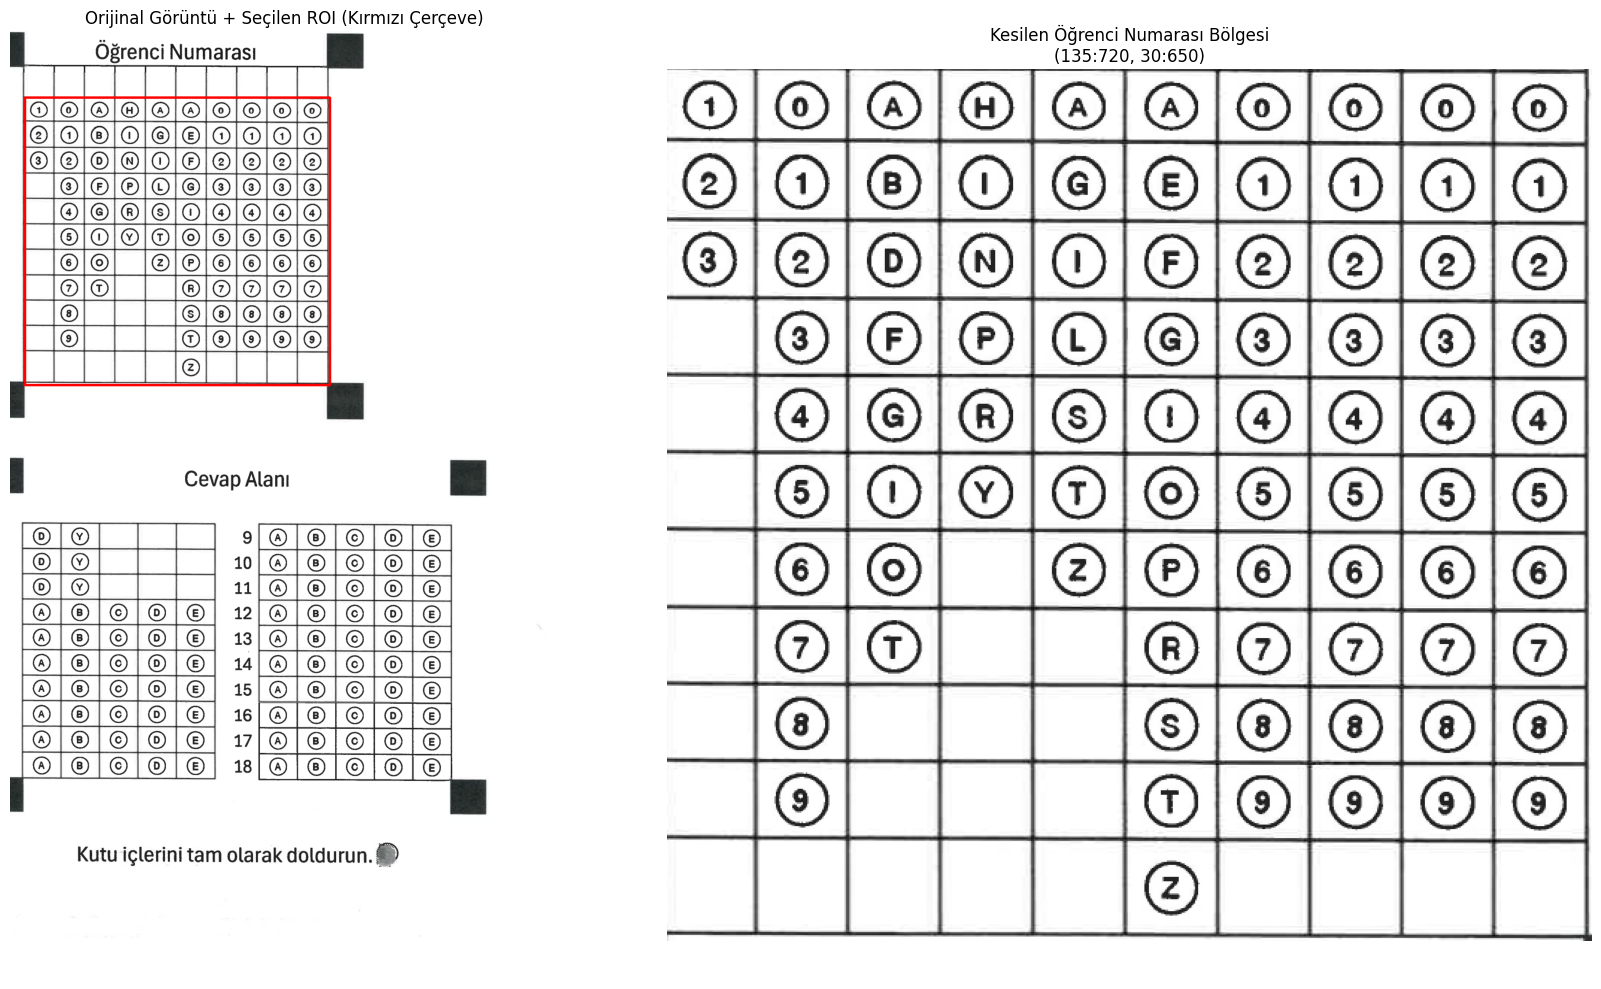

ROI Boyutu: 585 yükseklik x 620 genişlik
Koordinatlar: y1=135, y2=720, x1=30, x2=650
Kesilen bölge 'student_roi_kesilen.png' olarak kaydedildi.


In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ====================== AYARLAR ======================
image_path = 'optik_kirpilmis_resimler/ogrenci_1.png'   # <-- Dosya adını buraya yaz

# === BURAYI DÜZENLE ===
y1, y2 = 135, 720     # Üst ve alt sınır (y koordinatları)
x1, x2 = 30, 650     # Sol ve sağ sınır (x koordinatları)

# =====================================================

img = cv2.imread(image_path)
if img is None:
    print("Hata: Görüntü yüklenemedi!")
else:
    # Orijinal görüntü üzerinde kırmızı çerçeve çiz
    img_with_rect = img.copy()
    cv2.rectangle(img_with_rect, (x1, y1), (x2, y2), (0, 0, 255), 3)  # Kırmızı çerçeve
    
    # ROI'yi kes
    roi = img[y1:y2, x1:x2]
    
    # Matplotlib ile yan yana göster
    plt.figure(figsize=(18, 10))
    
    # 1. Orijinal görüntü + kırmızı çerçeve
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img_with_rect, cv2.COLOR_BGR2RGB))
    plt.title('Orijinal Görüntü + Seçilen ROI (Kırmızı Çerçeve)')
    plt.axis('off')
    
    # 2. Kesilen ROI
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
    plt.title(f'Kesilen Öğrenci Numarası Bölgesi\n({y1}:{y2}, {x1}:{x2})')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"ROI Boyutu: {roi.shape[0]} yükseklik x {roi.shape[1]} genişlik")
    print(f"Koordinatlar: y1={y1}, y2={y2}, x1={x1}, x2={x2}")
    
    # İstersen kesilen bölgeyi kaydet
    cv2.imwrite('student_roi_kesilen.png', roi)
    print("Kesilen bölge 'student_roi_kesilen.png' olarak kaydedildi.")

ROI Boyutu: 585 x 620 piksel
Sütunlar arası boşluk: 5 piksel


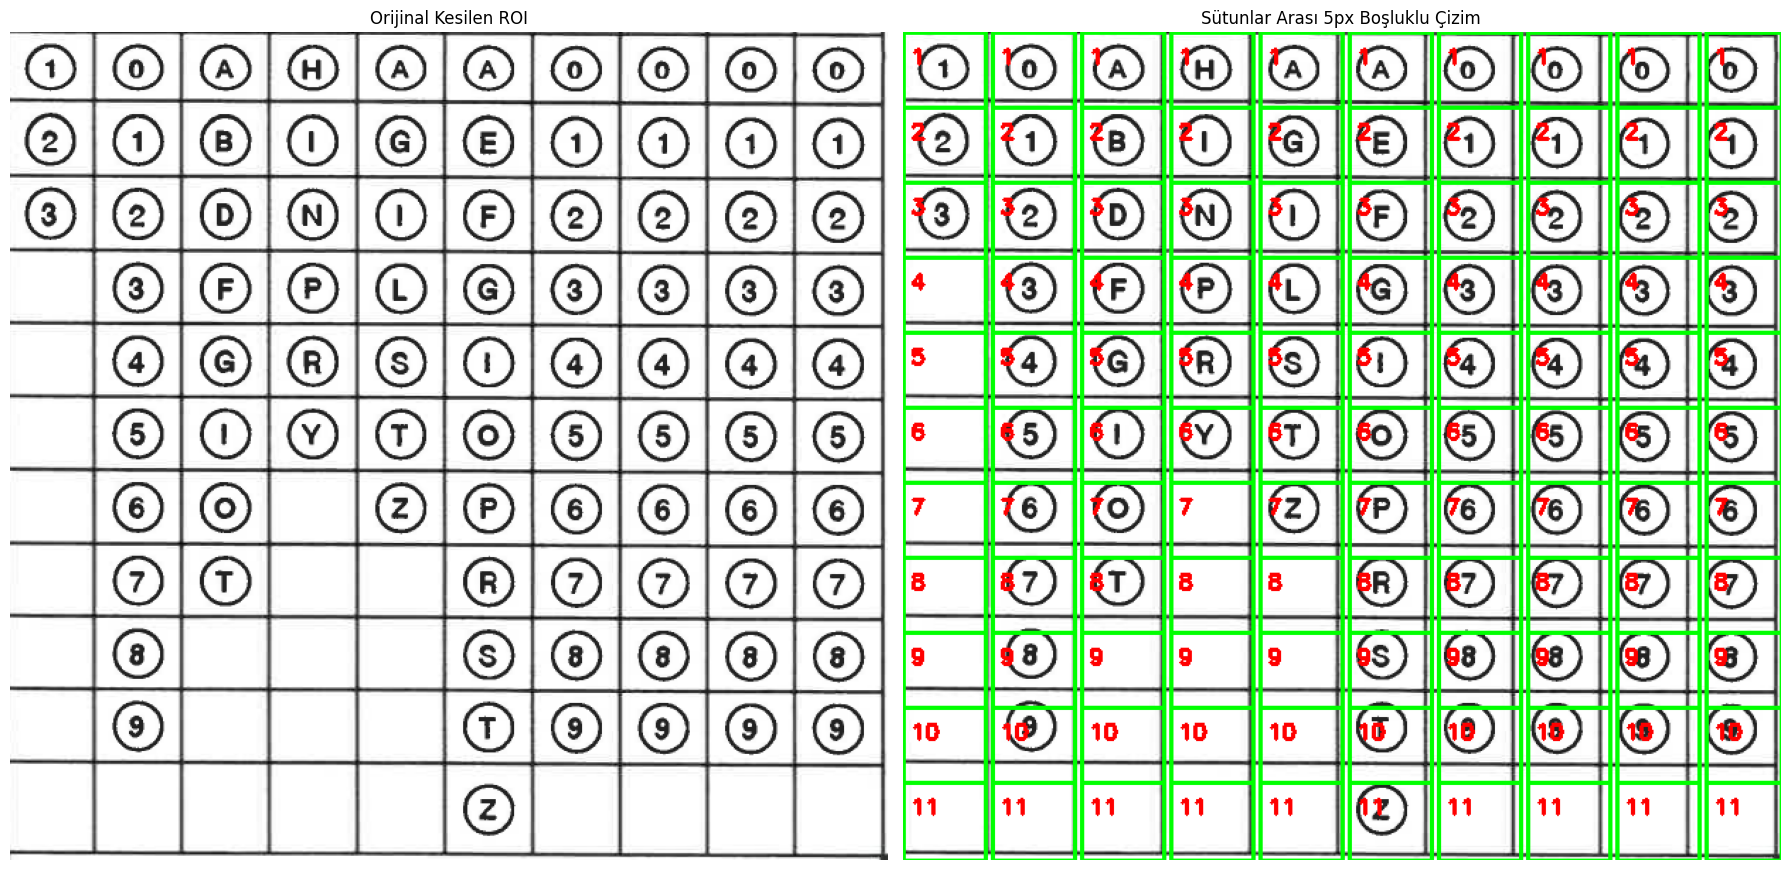

İşlem tamamlandı. Her sütun 58px genişliğinde ve aralarında 5px boşluk var.


In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ====================== AYARLAR ======================
image_path = 'optik_kirpilmis_resimler/ogrenci_1.png'

# ROI koordinatları
y1, y2 = 135, 720
x1, x2 = 30, 650

# Sütun ayarları
num_columns = 10
column_width = 58          # Her sütunun genişliği
gap = 5                    # Sütunlar arasındaki boşluk (piksel)

# HER SÜTUNU 11 EŞİT PARÇAYA BÖLECEĞİZ
rows_per_column = 11       

# =====================================================

img = cv2.imread(image_path)
if img is None:
    # Test amaçlı boş bir resim oluştur (Resim yolu hatalıysa hata almamak için)
    roi = np.zeros((y2-y1, x2-x1, 3), dtype=np.uint8)
else:
    roi = img[y1:y2, x1:x2].copy()

roi_draw = roi.copy()
height, width = roi.shape[:2]

print(f"ROI Boyutu: {height} x {width} piksel")
print(f"Sütunlar arası boşluk: {gap} piksel")

# Her sütun için işlem
for col in range(num_columns):
    # x_start hesaplanırken önceki sütunların genişliği + boşluklar eklenir
    x_start = col * (column_width + gap)
    x_end = x_start + column_width
    
    # ROI sınırlarını aşmamak için kontrol
    if x_start >= width:
        break
    if x_end > width:
        x_end = width
    
    # Her sütunu 11 eşit parçaya böl
    row_height = height // rows_per_column
    
    for row in range(rows_per_column):
        y_start = row * row_height
        y_end = y_start + row_height
        
        # Son satırda kalan pikselleri dahil et
        if row == rows_per_column - 1:
            y_end = height
        
        # Seçim kutucuğunu çiz
        cv2.rectangle(roi_draw, 
                     (x_start, y_start), 
                     (x_end, y_end), 
                     (0, 255, 0), 2)
        
        # Kutucuk numaralandırma
        cv2.putText(roi_draw, f"{row+1}", 
                   (x_start + 5, y_start + 22), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

# ====================== GÖRÜNTÜLEME ======================
plt.figure(figsize=(18, 11))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
plt.title('Orijinal Kesilen ROI')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(roi_draw, cv2.COLOR_BGR2RGB))
plt.title(f'Sütunlar Arası {gap}px Boşluklu Çizim')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"İşlem tamamlandı. Her sütun {column_width}px genişliğinde ve aralarında {gap}px boşluk var.")

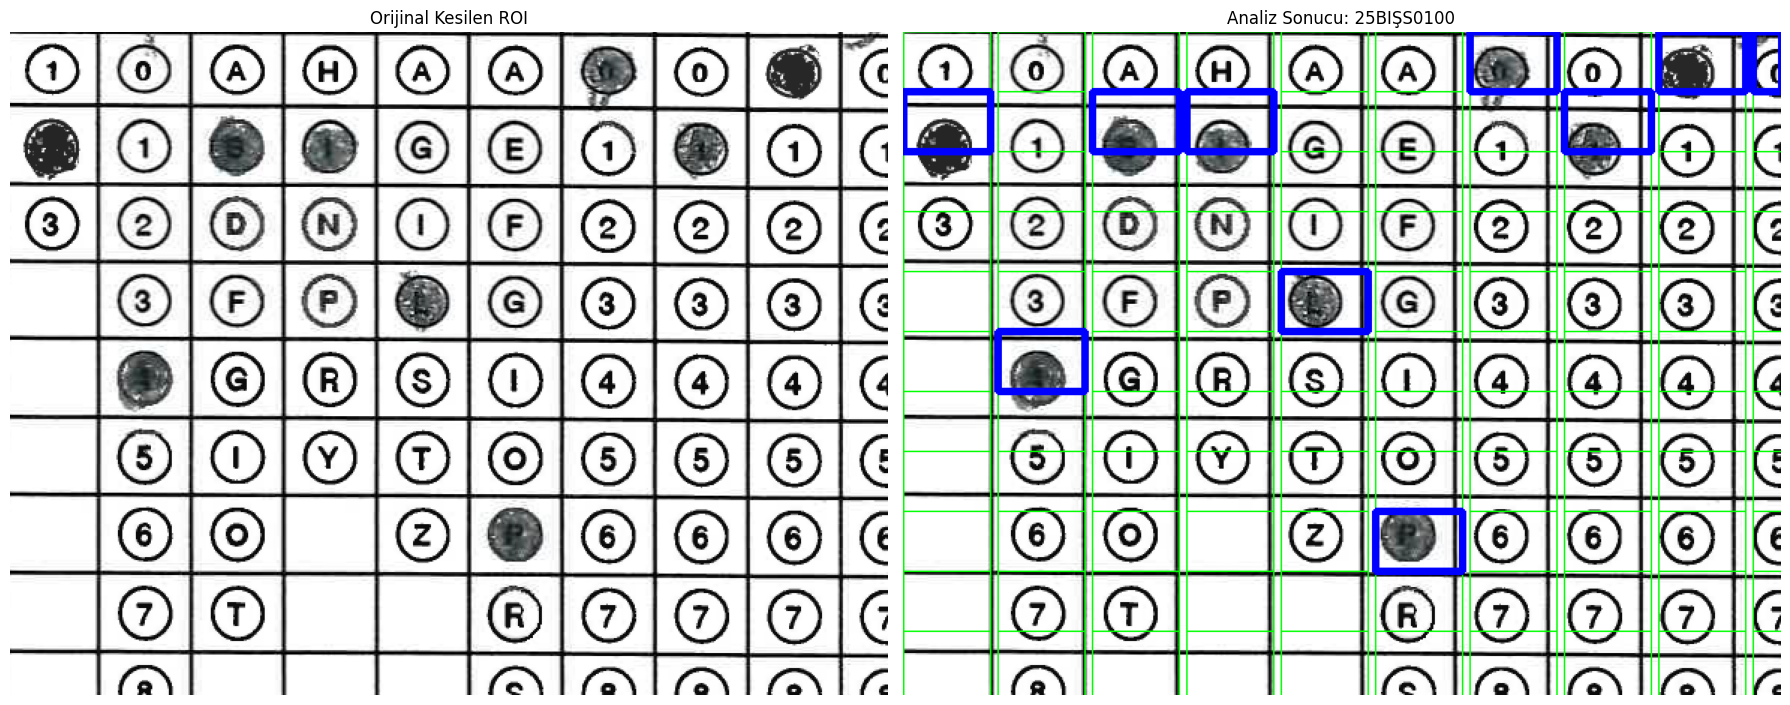

Okunan Kod: 25BIŞS0100


In [53]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ====================== AYARLAR ======================
image_path = 'optik_kirpilmis_resimler/ogrenci_6.png'

# ROI koordinatları
y1, y2 = 132, 575
x1, x2 = 36, 622
# x=36, y=132, w=622, h=575
# Sütun ayarları
num_columns = 10
column_width = 58          # Her sütunun genişliği
gap = 5                    # Sütunlar arasındaki boşluk (piksel)

# HER SÜTUNU 11 EŞİT PARÇAYA BÖLECEĞİZ
rows_per_column = 11       

# Karakter haritası
columns_map = [
    ["1", "2", "3"],                             # 1. Sütun
    ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"], # 2.
    ["A", "B", "D", "F", "G", "İ", "O", "T"],    # 3.
    ["H", "I", "N", "P", "R", "Y"],              # 4.
    ["A", "G", "İ", "L", "Ş", "T", "Z"],         # 5.
    ["A", "E", "F", "G", "İ", "Ö", "P", "R", "S", "T", "Z"], # 6.
    ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"], # 7.
    ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"], # 8.
    ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"], # 9.
    ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"]  # 10.
]

# Hassasiyet Ayarı (Kutucuğun % kaçı doluysa "işaretli" sayılsın?)
threshold_percent = 30 

# =====================================================

img = cv2.imread(image_path)
if img is None:
    roi = np.zeros((y2-y1, x2-x1, 3), dtype=np.uint8)
else:
    roi = img[y1:y2, x1:x2].copy()

# Analiz için görüntüyü hazırla (Gri tonlama ve eşikleme)
gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 170, 255, cv2.THRESH_BINARY_INV)

roi_draw = roi.copy()
height, width = roi.shape[:2]
final_results = []

# Her sütun için işlem
for col in range(num_columns):
    x_start = col * (column_width + gap)
    x_end = x_start + column_width
    
    if x_start >= width:
        break
    if x_end > width:
        x_end = width
    
    row_height = height // rows_per_column
    
    column_intensities = [] # Sütundaki her satırın koyuluk oranını tutar
    
    for row in range(rows_per_column):
        y_start = row * row_height
        y_end = y_start + row_height
        if row == rows_per_column - 1:
            y_end = height
        
        # SİYAH PİKSEL YOĞUNLUĞU ÖLÇÜMÜ
        cell_area = thresh[y_start:y_end, x_start:x_end]
        pixel_count = cv2.countNonZero(cell_area)
        density = (pixel_count / cell_area.size) * 100
        column_intensities.append(density)
        
        # Standart kutucuk çizimi
        cv2.rectangle(roi_draw, (x_start, y_start), (x_end, y_end), (0, 255, 0), 1)

    # BU SÜTUN İÇİN KARAR VERME
    max_val = max(column_intensities)
    max_idx = np.argmax(column_intensities)
    
    detected_char = "0" # Hiçbir şey bulunamazsa
    
    # Eğer en koyu kutucuk eşik değerinden büyükse ve map'te karşılığı varsa
    if max_val > threshold_percent:
        if max_idx < len(columns_map[col]):
            detected_char = columns_map[col][max_idx]
            # İşaretli kutuyu kalın çerçeveye al
            cv2.rectangle(roi_draw, (x_start, max_idx*row_height), (x_end, (max_idx+1)*row_height), (255, 0, 0), 3)

    final_results.append(detected_char)

# Sonucu metin olarak birleştir
result_string = "".join(final_results)

# ====================== GÖRÜNTÜLEME ======================
plt.figure(figsize=(18, 11))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
plt.title('Orijinal Kesilen ROI')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(roi_draw, cv2.COLOR_BGR2RGB))
plt.title(f'Analiz Sonucu: {result_string}')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Okunan Kod: {result_string}")

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ====================== AYARLAR ======================
image_path = 'optik_kirpilmis_resimler/ogrenci_4.png'

# Sütun ayarları (Sabit kalsın istediklerin)
num_columns = 10
column_width = 58
gap = 5
rows_per_column = 11
threshold_percent = 30 

columns_map = [
    ["1", "2", "3"],
    ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"],
    ["A", "B", "D", "F", "G", "İ", "O", "T"],
    ["H", "I", "N", "P", "R", "Y"],
    ["A", "G", "İ", "L", "Ş", "T", "Z"],
    ["A", "E", "F", "G", "İ", "Ö", "P", "R", "S", "T", "Z"],
    ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"],
    ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"],
    ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"],
    ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"]
]

# =====================================================

img = cv2.imread(image_path)
if img is None:
    print("Resim yüklenemedi!")
    exit()

# --- MOUSE İLE SEÇİM ARACI ---
print("LÜTFEN DİKKAT: Bir pencere açılacak.")
print("1. Mouse ile kutucukların olduğu alanı seç.")
print("2. Seçimi tamamlamak için ENTER veya SPACE tuşuna bas.")
print("3. İptal için 'c' tuşuna bas.")

# selectROI penceresini açar
# (pencere_adı, resim, showCrosshair, fromCenter)
bbox = cv2.selectROI("Alan Secimi", img, fromCenter=False, showCrosshair=True)

# Seçilen koordinatları al (x, y, genişlik, yükseklik)
x, y, w, h = bbox
cv2.destroyWindow("Alan Secimi") # Seçimden sonra pencereyi kapat

# ROI'yi kes
roi = img[y:y+h, x:x+w].copy()
roi_draw = roi.copy()

# Analiz hazırlığı
gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 170, 255, cv2.THRESH_BINARY_INV)

height, width = roi.shape[:2]
final_results = []

# Seçilen alana göre sütun ve satır analizi
for col in range(num_columns):
    x_start = col * (column_width + gap)
    x_end = x_start + column_width
    
    if x_start >= width: break
    
    row_height = height // rows_per_column
    column_intensities = []
    
    for row in range(rows_per_column):
        y_start = row * row_height
        y_end = y_start + row_height if row != rows_per_column - 1 else height
        
        cell_area = thresh[y_start:y_end, x_start:x_end]
        if cell_area.size == 0: continue
            
        pixel_count = cv2.countNonZero(cell_area)
        density = (pixel_count / cell_area.size) * 100
        column_intensities.append(density)
        cv2.rectangle(roi_draw, (x_start, y_start), (x_end, y_end), (0, 255, 0), 1)

    if column_intensities:
        max_val = max(column_intensities)
        max_idx = np.argmax(column_intensities)
        detected_char = "0"
        
        if max_val > threshold_percent and max_idx < len(columns_map[col]):
            detected_char = columns_map[col][max_idx]
            cv2.rectangle(roi_draw, (x_start, max_idx*row_height), 
                         (x_end, (max_idx+1)*row_height), (255, 0, 0), 2)
        final_results.append(detected_char)

result_string = "".join(final_results)

# ====================== GÖRÜNTÜLEME ======================
plt.figure(figsize=(12, 6))
plt.imshow(cv2.cvtColor(roi_draw, cv2.COLOR_BGR2RGB))
plt.title(f"Secilen Alan Analizi: {result_string}")
plt.axis('off')
plt.show()

print(f"Secilen Koordinatlar: x={x}, y={y}, w={w}, h={h}")
print(f"Okunan Kod: {result_string}")

LÜTFEN DİKKAT: Bir pencere açılacak.
1. Mouse ile kutucukların olduğu alanı seç.
2. Seçimi tamamlamak için ENTER veya SPACE tuşuna bas.
3. İptal için 'c' tuşuna bas.


error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'



ÖĞRENCİ NO: 25BILP0023
------------------------------
CEVAPLAR (1-8): ['D', 'Y', 'Y', 'C', 'A', 'C', 'B', 'B', 'A', 'B']
CEVAPLAR (9-18): ['E', 'C', 'E', 'B', 'A', 'C', 'A', 'B', 'E', 'C']


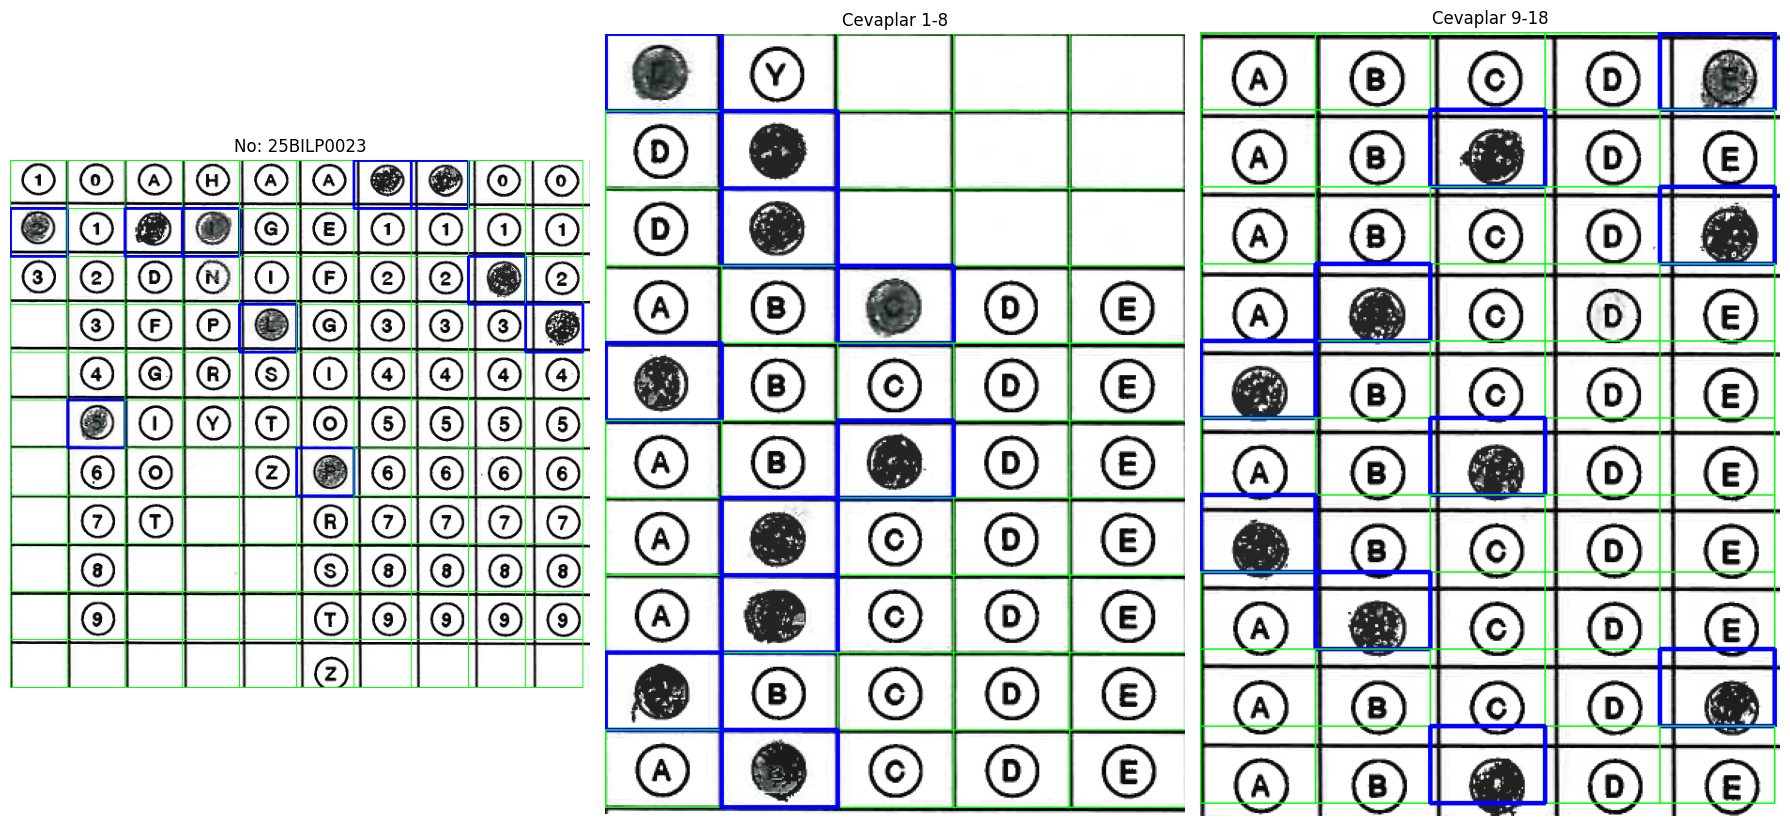

In [67]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ====================== AYARLAR & MAPS ======================
image_path = 'optik_kirpilmis_resimler/ogrenci_2.png'
threshold_percent = 30  # İşaretleme hassasiyeti

# 1. ÖĞRENCİ NUMARASI HARİTASI
num_columns_map = [
    ["1", "2", "3"], ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"],
    ["A", "B", "D", "F", "G", "İ", "O", "T"], ["H", "I", "N", "P", "R", "Y"],
    ["A", "G", "İ", "L", "Ş", "T", "Z"], ["A", "E", "F", "G", "İ", "Ö", "P", "R", "S", "T", "Z"],
    ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"], ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"],
    ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"], ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"]
]

# 2. CEVAP ALANI 1 (SOL TABLO: 1a-8)
answers_map_1 = [
    {"label": "1a", "opts": ["D", "Y"]}, {"label": "1b", "opts": ["D", "Y"]}, {"label": "1c", "opts": ["D", "Y"]},
    {"label": "2",  "opts": ["A", "B", "C", "D", "E"]}, {"label": "3",  "opts": ["A", "B", "C", "D", "E"]},
    {"label": "4",  "opts": ["A", "B", "C", "D", "E"]}, {"label": "5",  "opts": ["A", "B", "C", "D", "E"]},
    {"label": "6",  "opts": ["A", "B", "C", "D", "E"]}, {"label": "7",  "opts": ["A", "B", "C", "D", "E"]},
    {"label": "8",  "opts": ["A", "B", "C", "D", "E"]}
]

# 3. CEVAP ALANI 2 (SAĞ TABLO: 9-18)
# Hepsi A, B, C, D, E seçeneklerinden oluşuyor
answers_map_2 = [{"label": str(i), "opts": ["A", "B", "C", "D", "E"]} for i in range(9, 19)]

# ====================== YARDIMCI FONKSİYONLAR ======================

def get_roi_properly(img, title):
    """Resmin tamamını gösteren ve seçim yaptıran fonksiyon"""
    cv2.namedWindow(title, cv2.WINDOW_NORMAL)
    cv2.resizeWindow(title, 800, 1000) # Pencereyi yönetilebilir boyuta getir
    bbox = cv2.selectROI(title, img, fromCenter=False, showCrosshair=True)
    cv2.destroyWindow(title)
    return bbox

def analyze_area(image, box, row_count, col_count, mapping, mode="col"):
    """Seçilen alanı analiz eder ve sonuçları döndürür"""
    x, y, w, h = box
    if w == 0 or h == 0: return None, []
    
    roi = image[y:y+h, x:x+w].copy()
    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    # Eşikleme: İşaretleri belirginleştir
    _, thresh = cv2.threshold(gray, 160, 255, cv2.THRESH_BINARY_INV)
    
    detected = []
    r_h = h // row_count
    c_w = w // col_count
    
    # mode "col" ise sütun sütun (Öğrenci No), değilse satır satır (Cevaplar) döner
    outer_loop = col_count if mode=="col" else row_count
    inner_loop = row_count if mode=="col" else col_count
    
    for i in range(outer_loop):
        intensities = []
        for j in range(inner_loop):
            if mode == "col":
                curr_x, curr_y = i * c_w, j * r_h
            else:
                curr_x, curr_y = j * c_w, i * r_h
                
            cell = thresh[curr_y:curr_y+r_h, curr_x:curr_x+c_w]
            density = (cv2.countNonZero(cell) / cell.size) * 100
            intensities.append(density)
            cv2.rectangle(roi, (curr_x, curr_y), (curr_x+c_w, curr_y+r_h), (0, 255, 0), 1)

        max_idx = np.argmax(intensities)
        if intensities[max_idx] > threshold_percent:
            if mode == "col":
                val = mapping[i][max_idx] if max_idx < len(mapping[i]) else "?"
                cv2.rectangle(roi, (i*c_w, max_idx*r_h), ((i+1)*c_w, (max_idx+1)*r_h), (255, 0, 0), 2)
            else:
                opts = mapping[i]["opts"]
                val = opts[max_idx] if max_idx < len(opts) else "Boş"
                cv2.rectangle(roi, (max_idx*c_w, i*r_h), ((max_idx+1)*c_w, (i+1)*r_h), (255, 0, 0), 2)
            detected.append(val)
        else:
            detected.append("0" if mode=="col" else "Boş")
            
    return roi, detected

# ====================== ANA AKIŞ ======================

img = cv2.imread(image_path)
if img is None:
    print(f"Hata: {image_path} bulunamadı!")
    exit()

# Adım 1: Öğrenci No Seçimi
roi_num_box = get_roi_properly(img, "1. Ogrenci Numarasi Secimi")

# Adım 2: Sol Cevap Alanı (1-8)
roi_ans1_box = get_roi_properly(img, "2. Sol Cevap Alani (1-8) Secimi")

# Adım 3: Sağ Cevap Alanı (9-18)
roi_ans2_box = get_roi_properly(img, "3. Sag Cevap Alani (9-18) Secimi")

# ANALİZLER
roi_num_res, num_res = analyze_area(img, roi_num_box, 11, 10, num_columns_map, mode="col")
roi_ans1_res, ans1_res = analyze_area(img, roi_ans1_box, 10, 5, answers_map_1, mode="row")
roi_ans2_res, ans2_res = analyze_area(img, roi_ans2_box, 10, 5, answers_map_2, mode="row")

# SONUÇLARI EKRANA YAZDIR
print("\n" + "="*30)
print(f"ÖĞRENCİ NO: {''.join(num_res)}")
print("-" * 30)
print("CEVAPLAR (1-8):", ans1_res)
print("CEVAPLAR (9-18):", ans2_res)
print("="*30)

# ====================== GÖRÜNTÜLEME ======================
plt.figure(figsize=(18, 12))

# Öğrenci No Görseli
plt.subplot(1, 3, 1)
if roi_num_res is not None:
    plt.imshow(cv2.cvtColor(roi_num_res, cv2.COLOR_BGR2RGB))
plt.title(f"No: {''.join(num_res)}")
plt.axis('off')

# Sol Cevap Alanı Görseli
plt.subplot(1, 3, 2)
if roi_ans1_res is not None:
    plt.imshow(cv2.cvtColor(roi_ans1_res, cv2.COLOR_BGR2RGB))
plt.title("Cevaplar 1-8")
plt.axis('off')

# Sağ Cevap Alanı Görseli
plt.subplot(1, 3, 3)
if roi_ans2_res is not None:
    plt.imshow(cv2.cvtColor(roi_ans2_res, cv2.COLOR_BGR2RGB))
plt.title("Cevaplar 9-18")
plt.axis('off')

plt.tight_layout()
plt.show()


Excel OK! Öğrenci: 23BILP0013 Puan: 25


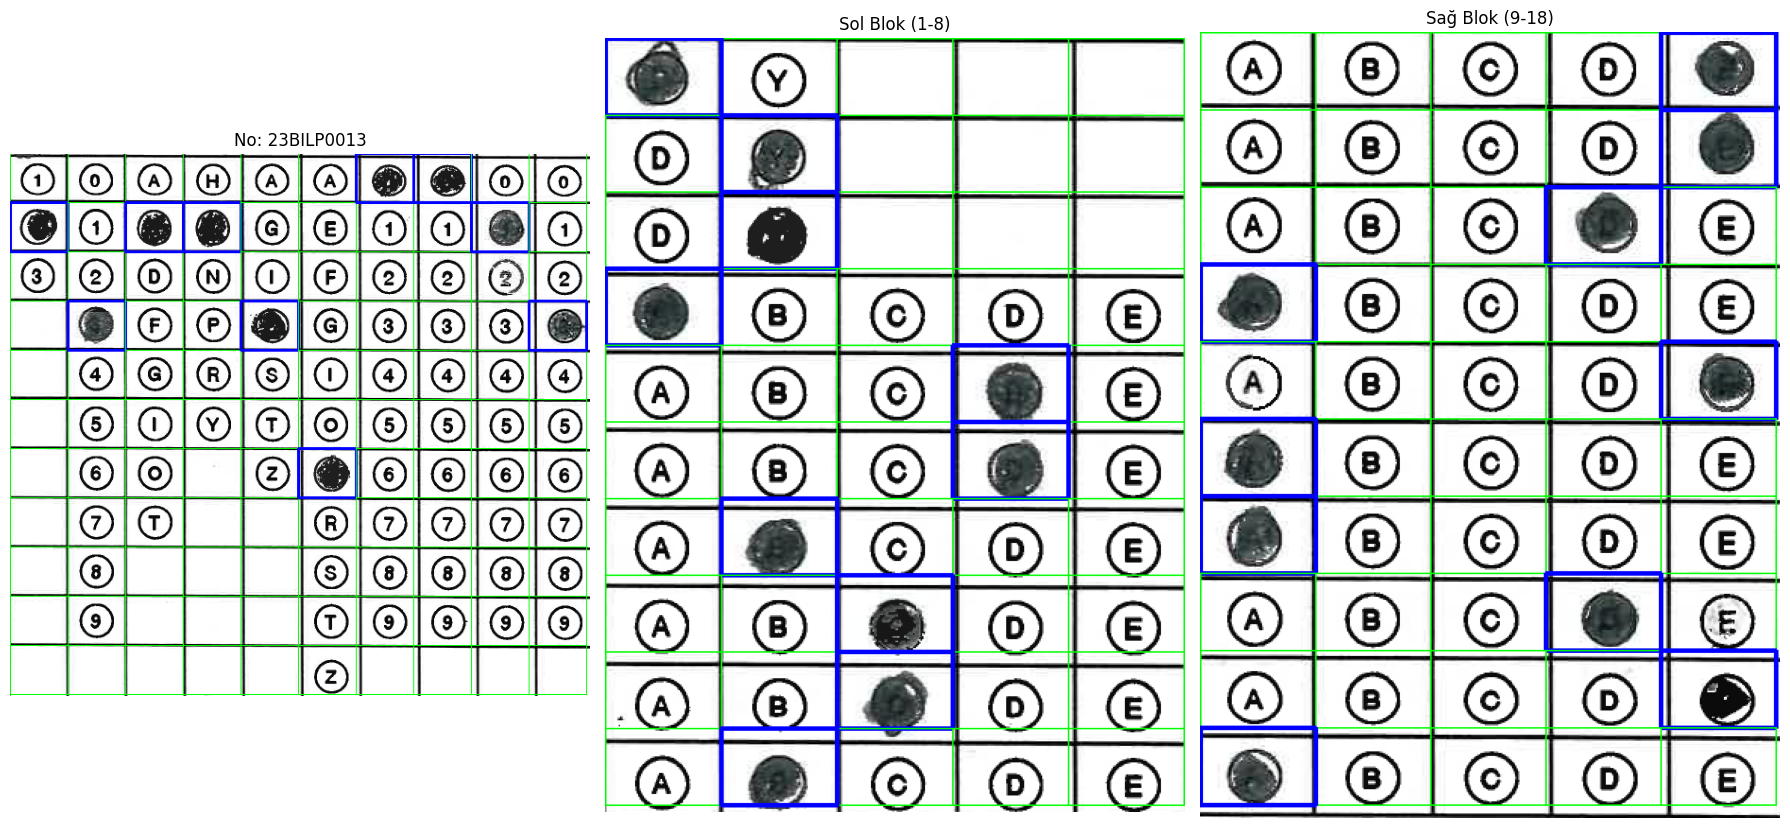

In [69]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ====================== AYARLAR & CEVAP ANAHTARI ======================
image_path = 'optik_kirpilmis_resimler/ogrenci_4.png'
threshold_percent = 25  # %35 çok yüksek olabilir, %20-25 daha güvenlidir

cevap_anahtari = [
    "D", "Y", "D",              # 1a, 1b, 1c
    "A", "B", "C", "D", "E",    # 2 - 6
    "A", "B",                   # 7 - 8
    "C", "D", "E", "A", "B", "C", "D", "E", "A", "B" # 9 - 18
]
soru_puanı = 5

# ====================== MAPS ======================
num_columns_map = [
    ["1", "2", "3"], ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"],
    ["A", "B", "D", "F", "G", "İ", "O", "T"], ["H", "I", "N", "P", "R", "Y"],
    ["A", "G", "İ", "L", "Ş", "T", "Z"], ["A", "E", "F", "G", "İ", "Ö", "P", "R", "S", "T", "Z"],
    ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"], ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"],
    ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"], ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"]
]

answers_map_1 = [
    {"label": "1a", "opts": ["D", "Y"]}, {"label": "1b", "opts": ["D", "Y"]}, {"label": "1c", "opts": ["D", "Y"]},
    {"label": "2",  "opts": ["A", "B", "C", "D", "E"]}, {"label": "3",  "opts": ["A", "B", "C", "D", "E"]},
    {"label": "4",  "opts": ["A", "B", "C", "D", "E"]}, {"label": "5",  "opts": ["A", "B", "C", "D", "E"]},
    {"label": "6",  "opts": ["A", "B", "C", "D", "E"]}, {"label": "7",  "opts": ["A", "B", "C", "D", "E"]},
    {"label": "8",  "opts": ["A", "B", "C", "D", "E"]}
]
answers_map_2 = [{"label": str(i), "opts": ["A", "B", "C", "D", "E"]} for i in range(9, 19)]

# ====================== FONKSİYONLAR ======================

def get_roi_properly(img, title):
    cv2.namedWindow(title, cv2.WINDOW_NORMAL)
    cv2.resizeWindow(title, 800, 1000)
    bbox = cv2.selectROI(title, img, fromCenter=False, showCrosshair=True)
    cv2.destroyWindow(title)
    return bbox

def analyze_area(image, box, row_count, col_count, mapping, mode="col"):
    x, y, w, h = box
    if w == 0 or h == 0: return None, []
    roi = image[y:y+h, x:x+w].copy()
    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    # Eşikleme (160 değeri idealdir, çok karanlıksa 140'a düşürebilirsin)
    _, thresh = cv2.threshold(gray, 160, 255, cv2.THRESH_BINARY_INV)
    
    detected = []
    r_h, c_w = h // row_count, w // col_count
    
    outer = col_count if mode=="col" else row_count
    inner = row_count if mode=="col" else col_count
    
    for i in range(outer):
        intensities = []
        for j in range(inner):
            curr_x, curr_y = (i*c_w, j*r_h) if mode=="col" else (j*c_w, i*r_h)
            cell = thresh[curr_y:curr_y+r_h, curr_x:curr_x+c_w]
            density = (cv2.countNonZero(cell) / cell.size) * 100
            intensities.append(density)
            # Hücre sınırlarını yeşil çiz (Görsel doğrulama için)
            cv2.rectangle(roi, (curr_x, curr_y), (curr_x+c_w, curr_y+r_h), (0, 255, 0), 1)

        max_idx = np.argmax(intensities)
        if intensities[max_idx] > threshold_percent:
            # İşaretli bulunan yeri mavi ile boya
            if mode == "col":
                curr_x, curr_y = i * c_w, max_idx * r_h
                val = mapping[i][max_idx] if max_idx < len(mapping[i]) else "?"
            else:
                curr_x, curr_y = max_idx * c_w, i * r_h
                val = mapping[i]["opts"][max_idx] if max_idx < len(mapping[i]["opts"]) else "Hata"
            
            cv2.rectangle(roi, (curr_x, curr_y), (curr_x+c_w, curr_y+r_h), (255, 0, 0), 2)
            detected.append(val)
        else:
            detected.append("Boş")
            
    return roi, detected

# ====================== İŞLEME ======================

img = cv2.imread(image_path)
if img is None:
    print("Resim yüklenemedi!"); exit()

roi_num_box = get_roi_properly(img, "1. Ogrenci No")
roi_ans1_box = get_roi_properly(img, "2. Sorular 1-8")
roi_ans2_box = get_roi_properly(img, "3. Sorular 9-18")

# Görsel sonuçları (roi_..._res) saklıyoruz ki plot edebilelim
roi_num_res, num_res = analyze_area(img, roi_num_box, 11, 10, num_columns_map, mode="col")
roi_ans1_res, ans1_res = analyze_area(img, roi_ans1_box, 10, 5, answers_map_1, mode="row")
roi_ans2_res, ans2_res = analyze_area(img, roi_ans2_box, 10, 5, answers_map_2, mode="row")

ogrenci_no = "".join(num_res).replace("Boş", "0")
tum_cevaplar = ans1_res + ans2_res

# ====================== EXCEL ======================
sutun_isimleri = ["Öğrenci No"] + [f"Soru_{m['label']}" for m in (answers_map_1 + answers_map_2)]
df1 = pd.DataFrame([[ogrenci_no] + tum_cevaplar], columns=sutun_isimleri)

puanlar = [soru_puanı if tum_cevaplar[i] == cevap_anahtari[i] else 0 for i in range(len(tum_cevaplar))]
df2 = pd.DataFrame([[ogrenci_no] + puanlar + [sum(puanlar)]], columns=sutun_isimleri + ["Toplam Puan"])

with pd.ExcelWriter("Optik_Sonuclar.xlsx", engine="openpyxl") as writer:
    df1.to_excel(writer, sheet_name="Isaretlenenler", index=False)
    df2.to_excel(writer, sheet_name="Puanlar", index=False)

print(f"\nExcel OK! Öğrenci: {ogrenci_no} Puan: {sum(puanlar)}")

# ====================== GÖRÜNTÜLEME ======================
plt.figure(figsize=(18, 10))

plt.subplot(1, 3, 1)
if roi_num_res is not None:
    plt.imshow(cv2.cvtColor(roi_num_res, cv2.COLOR_BGR2RGB))
plt.title(f"No: {ogrenci_no}")
plt.axis('off')

plt.subplot(1, 3, 2)
if roi_ans1_res is not None:
    plt.imshow(cv2.cvtColor(roi_ans1_res, cv2.COLOR_BGR2RGB))
plt.title("Sol Blok (1-8)")
plt.axis('off')

plt.subplot(1, 3, 3)
if roi_ans2_res is not None:
    plt.imshow(cv2.cvtColor(roi_ans2_res, cv2.COLOR_BGR2RGB))
plt.title("Sağ Blok (9-18)")
plt.axis('off')

plt.tight_layout()
plt.show()

Secilen Koordinatlar: x=36, y=132, w=622, h=575
Bu çok iyi

In [70]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import glob

# ====================== AYARLAR & CEVAP ANAHTARI ======================
folder_path = 'optik_kirpilmis_resimler'  # Klasör adı
threshold_percent = 25 
soru_puanı = 5

cevap_anahtari = [
    "D", "Y", "D",              # 1a, 1b, 1c
    "A", "B", "C", "D", "E",    # 2 - 6
    "A", "B",                   # 7 - 8
    "C", "D", "E", "A", "B", "C", "D", "E", "A", "B" # 9 - 18
]

# ====================== MAPS ======================
num_columns_map = [
    ["1", "2", "3"], ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"],
    ["A", "B", "D", "F", "G", "İ", "O", "T"], ["H", "I", "N", "P", "R", "Y"],
    ["A", "G", "İ", "L", "Ş", "T", "Z"], ["A", "E", "F", "G", "İ", "Ö", "P", "R", "S", "T", "Z"],
    ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"], ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"],
    ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"], ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"]
]

answers_map_1 = [
    {"label": "1a", "opts": ["D", "Y"]}, {"label": "1b", "opts": ["D", "Y"]}, {"label": "1c", "opts": ["D", "Y"]},
    {"label": "2",  "opts": ["A", "B", "C", "D", "E"]}, {"label": "3",  "opts": ["A", "B", "C", "D", "E"]},
    {"label": "4",  "opts": ["A", "B", "C", "D", "E"]}, {"label": "5",  "opts": ["A", "B", "C", "D", "E"]},
    {"label": "6",  "opts": ["A", "B", "C", "D", "E"]}, {"label": "7",  "opts": ["A", "B", "C", "D", "E"]},
    {"label": "8",  "opts": ["A", "B", "C", "D", "E"]}
]
answers_map_2 = [{"label": str(i), "opts": ["A", "B", "C", "D", "E"]} for i in range(9, 19)]

# ====================== FONKSİYONLAR ======================

def get_roi_properly(img, title):
    cv2.namedWindow(title, cv2.WINDOW_NORMAL)
    cv2.resizeWindow(title, 800, 1000)
    bbox = cv2.selectROI(title, img, fromCenter=False, showCrosshair=True)
    cv2.destroyWindow(title)
    return bbox

def analyze_area(image, box, row_count, col_count, mapping, mode="col"):
    x, y, w, h = box
    if w == 0 or h == 0: return None, []
    roi = image[y:y+h, x:x+w].copy()
    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 160, 255, cv2.THRESH_BINARY_INV)
    
    detected = []
    r_h, c_w = h // row_count, w // col_count
    outer = col_count if mode=="col" else row_count
    inner = row_count if mode=="col" else col_count
    
    for i in range(outer):
        intensities = []
        for j in range(inner):
            curr_x, curr_y = (i*c_w, j*r_h) if mode=="col" else (j*c_w, i*r_h)
            cell = thresh[curr_y:curr_y+r_h, curr_x:curr_x+c_w]
            density = (cv2.countNonZero(cell) / cell.size) * 100
            intensities.append(density)
            cv2.rectangle(roi, (curr_x, curr_y), (curr_x+c_w, curr_y+r_h), (0, 255, 0), 1)

        max_idx = np.argmax(intensities)
        if intensities[max_idx] > threshold_percent:
            if mode == "col":
                curr_x, curr_y = i * c_w, max_idx * r_h
                val = mapping[i][max_idx] if max_idx < len(mapping[i]) else "?"
            else:
                curr_x, curr_y = max_idx * c_w, i * r_h
                val = mapping[i]["opts"][max_idx] if max_idx < len(mapping[i]["opts"]) else "Hata"
            
            cv2.rectangle(roi, (curr_x, curr_y), (curr_x+c_w, curr_y+r_h), (255, 0, 0), 2)
            detected.append(val)
        else:
            detected.append("Boş")
            
    return roi, detected

# ====================== TOPLU İŞLEME BAŞLIYOR ======================

# Klasördeki tüm PNG dosyalarını al
image_files = glob.glob(os.path.join(folder_path, "*.png"))

if not image_files:
    print(f"Hata: {folder_path} klasöründe PNG dosyası bulunamadı!")
    exit()

# 1. ADIM: KOORDİNATLARI BELİRLEME (Sadece ilk resim üzerinden)
print(f"Koordinat belirleme için {os.path.basename(image_files[0])} açılıyor...")
first_img = cv2.imread(image_files[0])

roi_num_box = get_roi_properly(first_img, "1. Ogrenci No (REFERANS)")
roi_ans1_box = get_roi_properly(first_img, "2. Sorular 1-8 (REFERANS)")
roi_ans2_box = get_roi_properly(first_img, "3. Sorular 9-18 (REFERANS)")

all_student_data = []
all_student_scores = []

# 2. ADIM: TÜM DOSYALARI DÖNGÜ İLE TARA
print("\nTarama başlatılıyor...")
for file in image_files:
    file_name = os.path.basename(file)
    img = cv2.imread(file)
    
    if img is None:
        print(f"Hata: {file_name} okunamadı, atlanıyor.")
        continue

    # Analizleri yap (Referans koordinatları kullanarak)
    _, num_res = analyze_area(img, roi_num_box, 11, 10, num_columns_map, mode="col")
    _, ans1_res = analyze_area(img, roi_ans1_box, 10, 5, answers_map_1, mode="row")
    _, ans2_res = analyze_area(img, roi_ans2_box, 10, 5, answers_map_2, mode="row")

    ogrenci_no = "".join(num_res).replace("Boş", "0")
    tum_cevaplar = ans1_res + ans2_res

    # Excel Sayfa 1 için veri (Şıklar)
    all_student_data.append([ogrenci_no] + tum_cevaplar)

    # Excel Sayfa 2 için veri (Puanlar)
    puanlar = [soru_puanı if tum_cevaplar[i] == cevap_anahtari[i] else 0 for i in range(len(tum_cevaplar))]
    toplam = sum(puanlar)
    all_student_scores.append([ogrenci_no] + puanlar + [toplam])
    
    print(f"İşlendi: {file_name} -> No: {ogrenci_no} | Puan: {toplam}")

# ====================== EXCEL KAYIT ======================
sutun_isimleri = ["Öğrenci No"] + [f"Soru_{m['label']}" for m in (answers_map_1 + answers_map_2)]
df1 = pd.DataFrame(all_student_data, columns=sutun_isimleri)

sutun_isimleri_puan = sutun_isimleri + ["Toplam Puan"]
df2 = pd.DataFrame(all_student_scores, columns=sutun_isimleri_puan)

with pd.ExcelWriter("Tum_Optik_Sonuclar.xlsx", engine="openpyxl") as writer:
    df1.to_excel(writer, sheet_name="Isaretlenenler", index=False)
    df2.to_excel(writer, sheet_name="Puanlar", index=False)

print("\n" + "="*40)
print(f"Toplam {len(all_student_data)} kağıt işlendi.")
print(f"Excel dosyası oluşturuldu: Tum_Optik_Sonuclar.xlsx")
print("="*40)

Koordinat belirleme için ogrenci_1.png açılıyor...

Tarama başlatılıyor...
İşlendi: ogrenci_1.png -> No: 2000000000 | Puan: 0
İşlendi: ogrenci_2.png -> No: 25BILP0023 | Puan: 35
İşlendi: ogrenci_3.png -> No: 25BILP0044 | Puan: 40
İşlendi: ogrenci_4.png -> No: 23BILP0013 | Puan: 25
İşlendi: ogrenci_5.png -> No: 24BILP0131 | Puan: 35
İşlendi: ogrenci_6.png -> No: 24BILP0109 | Puan: 40
İşlendi: ogrenci_7.png -> No: 25BILP0016 | Puan: 30
İşlendi: ogrenci_8.png -> No: 28BILP0048 | Puan: 30
İşlendi: ogrenci_9.png -> No: 25BILP0038 | Puan: 25

Toplam 9 kağıt işlendi.
Excel dosyası oluşturuldu: Tum_Optik_Sonuclar.xlsx


In [71]:
import cv2
import os
import glob
import numpy as np

# ====================== AYARLAR ======================
input_folder = 'optik_kirpilmis_resimler'
output_folder = 'dogrulama_resimleri' # Kontrol edeceğin resimler burada toplanacak

# Eğer klasör yoksa oluştur
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

print(f"Doğrulama resimleri '{output_folder}' klasörüne kaydedilecek...")

# ====================== İŞLEME DÖNGÜSÜ ======================

# Not: Bir önceki hücrede belirlediğin 'roi_num_box', 'roi_ans1_box' ve 
# 'roi_ans2_box' değişkenlerinin bellekte (RAM'de) hala duruyor olması gerekir.

image_files = glob.glob(os.path.join(input_folder, "*.png"))

for file in image_files:
    file_name = os.path.basename(file)
    img = cv2.imread(file)
    
    if img is None: continue

    # 1. Analizleri yap ve görselleştirilmiş (çizimli) hallerini al
    # analyze_area fonksiyonun roi'yi çizip geri döndürdüğü için onu kullanıyoruz
    roi_n, _ = analyze_area(img, roi_num_box, 11, 10, num_columns_map, mode="col")
    roi_a1, _ = analyze_area(img, roi_ans1_box, 10, 5, answers_map_1, mode="row")
    roi_a2, _ = analyze_area(img, roi_ans2_box, 10, 5, answers_map_2, mode="row")

    # 2. Bu üç parçayı tek bir resimde yan yana birleştir (Opsiyonel ama hızlı kontrol için en iyisi)
    # Resim yüksekliklerini eşitlemek için en büyük yüksekliği bulalım
    h1, w1 = roi_n.shape[:2]
    h2, w2 = roi_a1.shape[:2]
    h3, w3 = roi_a2.shape[:2]
    max_h = max(h1, h2, h3)

    # Resimleri aynı yüksekliğe getir (Altına siyah boşluk ekleyerek)
    def pad_image(image, target_h):
        h, w = image.shape[:2]
        pad = np.zeros((target_h - h, w, 3), dtype=np.uint8)
        return np.vstack((image, pad))

    roi_n_pad = pad_image(roi_n, max_h)
    roi_a1_pad = pad_image(roi_a1, max_h)
    roi_a2_pad = pad_image(roi_a2, max_h)

    # Aralara ince beyaz bir çizgi ekleyerek yan yana birleştir
    divider = np.ones((max_h, 10, 3), dtype=np.uint8) * 255
    combined_res = np.hstack((roi_n_pad, divider, roi_a1_pad, divider, roi_a2_pad))

    # 3. Kaydet
    save_path = os.path.join(output_folder, f"check_{file_name}")
    cv2.imwrite(save_path, combined_res)

print(f"İşlem bitti! Toplam {len(image_files)} adet doğrulama resmi hazır.")

Doğrulama resimleri 'dogrulama_resimleri' klasörüne kaydedilecek...
İşlem bitti! Toplam 9 adet doğrulama resmi hazır.
